In [15]:
!pip install pingouin

!pip install statsmodels

!pip install gdown

In [16]:
import gdown

import os

import pandas as pd
import numpy as np
import pingouin as pg
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import boxcox
import scipy.stats as stats
from statsmodels.multivariate.manova import MANOVA
from IPython.display import display

import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [17]:

file_id = "1L2qfB-FNhUUVBulctGzsmDT2QPnPdWx4"
file_url = f"https://drive.google.com/uc?id={file_id}"
output = "HATCO_clean.csv"

gdown.download(file_url, output, quiet=False)

print("\n Creating DataFrame ... \n")

# Load the clean CSV
df = pd.read_csv(output)

print("Shape:", df.shape)        # should be (100, 15)
print(df.head())                 # first 5 rows
print(df.dtypes)                 # column types

Downloading...
From: https://drive.google.com/uc?id=1L2qfB-FNhUUVBulctGzsmDT2QPnPdWx4
To: /content/HATCO_clean.csv
100%|██████████| 4.93k/4.93k [00:00<00:00, 7.00MB/s]


 Creating DataFrame ... 

Shape: (100, 15)
   id  delivery_speed  price_level  price_flexibility  manufacturer_image  \
0   1             4.1          0.6                6.9                 4.7   
1   2             1.8          3.0                6.3                 6.6   
2   3             3.4          5.2                5.7                 6.0   
3   4             2.7          1.0                7.1                 5.9   
4   5             6.0          0.9                9.6                 7.8   

   service_level  salesforce_image  product_quality  firm_size  usage_level  \
0            2.4               2.3              5.2          0           32   
1            2.5               4.0              8.4          1           43   
2            4.3               2.7              8.2          1           48   
3            1.8               2.3              7.8          0           32   
4            3.4               4.6              4.5          2           58   

   satisfaction  s

In [18]:
# ─────────────────────────────────────────────
#  SECTION 1 — VARIABLES CLASSIFICATION
# ─────────────────────────────────────────────

# Separate metric vs non-metric columns
metric_cols    = ['delivery_speed', 'price_level', 'price_flexibility',
                  'manufacturer_image', 'service_level', 'salesforce_image',
                  'product_quality', 'usage_level', 'satisfaction']

nonmetric_cols = ['buying_situation', 'spec_buying', 'procurement_structure',
                  'industry_type', 'buying_situation']

print("\n--- Metric variables ---")
print(df[metric_cols].head())

print("\n--- Non-Metric variables ---")
print(df[nonmetric_cols].head())



--- Metric variables ---
   delivery_speed  price_level  price_flexibility  manufacturer_image  \
0             4.1          0.6                6.9                 4.7   
1             1.8          3.0                6.3                 6.6   
2             3.4          5.2                5.7                 6.0   
3             2.7          1.0                7.1                 5.9   
4             6.0          0.9                9.6                 7.8   

   service_level  salesforce_image  product_quality  usage_level  satisfaction  
0            2.4               2.3              5.2           32           4.2  
1            2.5               4.0              8.4           43           4.3  
2            4.3               2.7              8.2           48           5.2  
3            1.8               2.3              7.8           32           3.9  
4            3.4               4.6              4.5           58           6.8  

--- Non-Metric variables ---
   buying_situation

In [19]:
# ─────────────────────────────────────────────
#  SECTION 2A — FREQUENCY TABLES (Non-Metric)
# ─────────────────────────────────────────────

print("\n========== FREQUENCY TABLES ==========")

# Prepare data for export
freq_tables = {}

for col in nonmetric_cols:
    freq  = df[col].value_counts().sort_index()
    rel   = df[col].value_counts(normalize=True).sort_index().round(3) * 100
    table = pd.DataFrame({'Count': freq, 'Percent %': rel})
    freq_tables[col] = table
    print(f"\n[{col}]")
    print(table)



========== FREQUENCY TABLES ==========

[buying_situation]
                  Count  Percent %
buying_situation                  
1                    34       34.0
2                    32       32.0
3                    34       34.0

[spec_buying]
             Count  Percent %
spec_buying                  
0               40       40.0
1               60       60.0

[procurement_structure]
                       Count  Percent %
procurement_structure                  
0                         50       50.0
1                         50       50.0

[industry_type]
               Count  Percent %
industry_type                  
0                 50       50.0
1                 50       50.0

[buying_situation]
                  Count  Percent %
buying_situation                  
1                    34       34.0
2                    32       32.0
3                    34       34.0


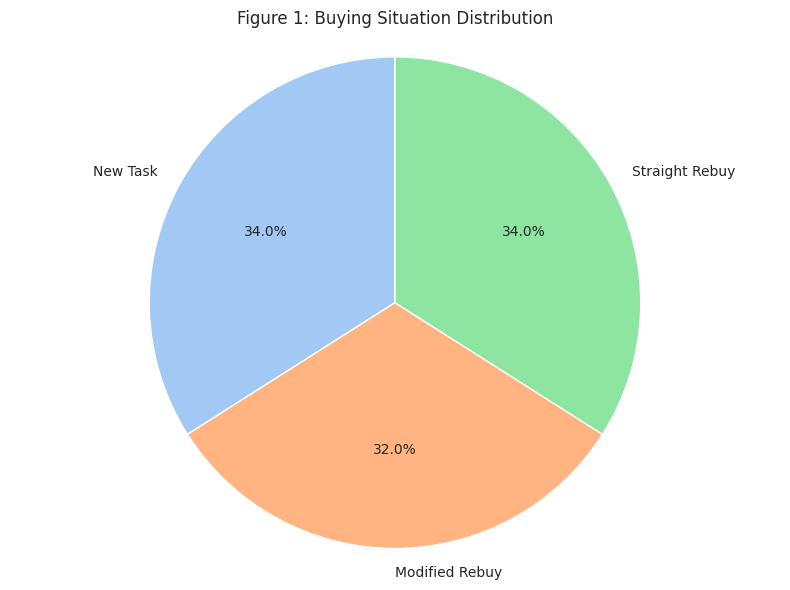

Saved: plots/Figure_01_buying_situation_piechart.png


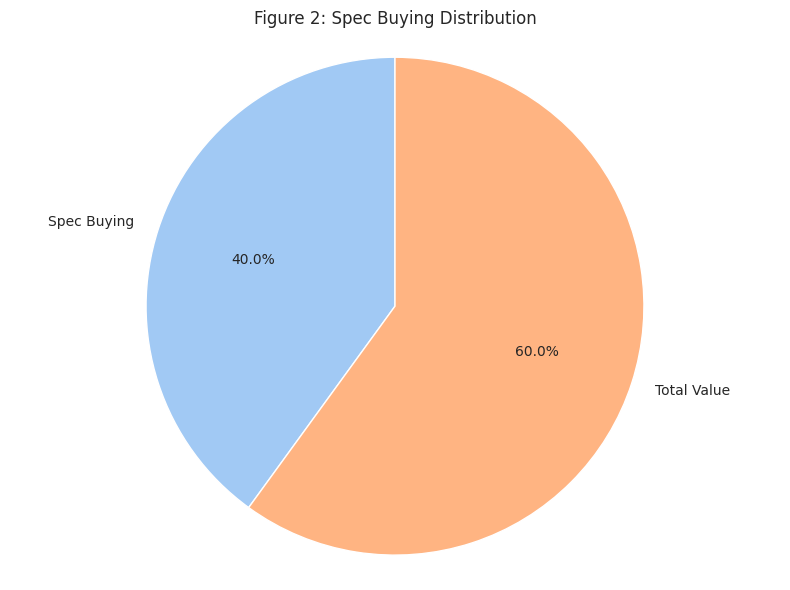

Saved: plots/Figure_02_spec_buying_piechart.png


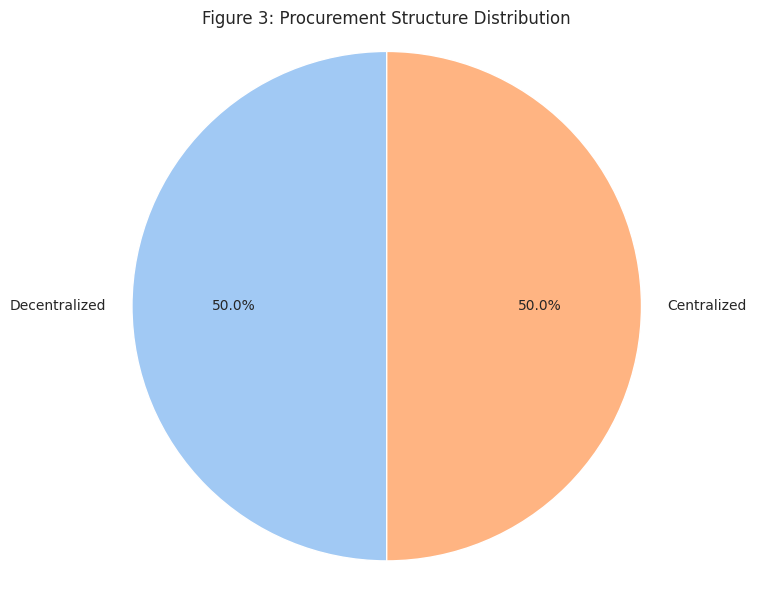

Saved: plots/Figure_03_procurement_structure_piechart.png


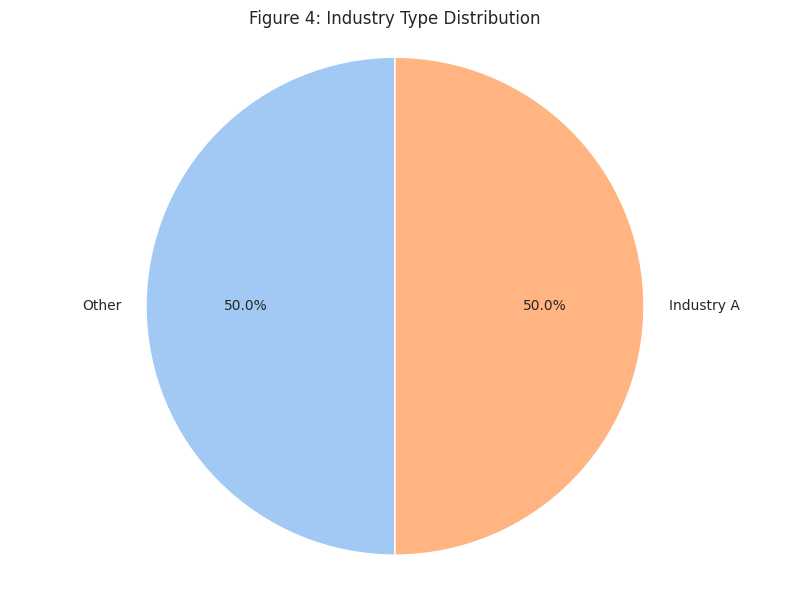

Saved: plots/Figure_04_industry_type_piechart.png


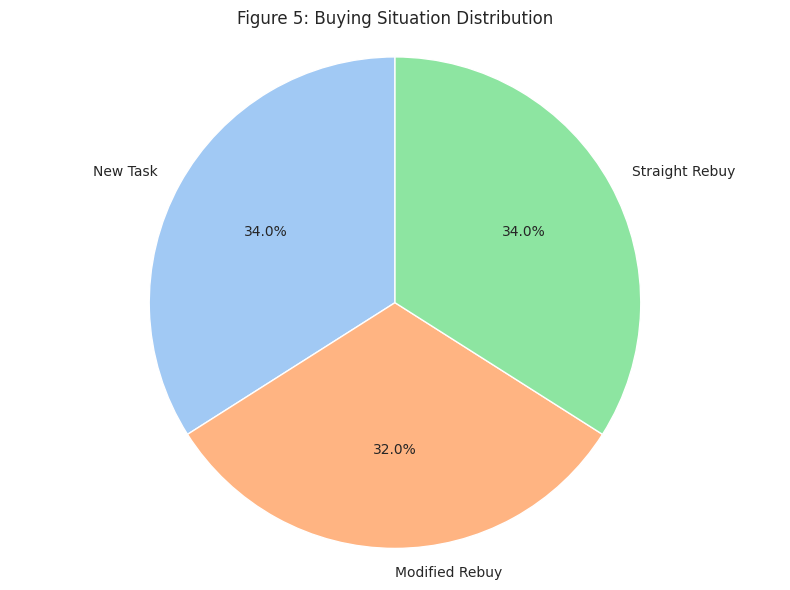

Saved: plots/Figure_05_buying_situation_piechart.png
All pie charts saved separately.

========== DESCRIPTIVE STATISTICS ==========
                     mean    50%   std   std   min   max  range    25%    75%  \
delivery_speed       3.52   3.40  1.32  1.32   0.0   6.1    6.1   2.50   4.60   
price_level          2.36   2.15  1.20  1.20   0.2   5.4    5.2   1.48   3.22   
price_flexibility    7.89   8.05  1.39  1.39   5.0  10.0    5.0   6.70   9.10   
manufacturer_image   5.25   5.00  1.13  1.13   2.5   8.2    5.7   4.57   6.00   
service_level        2.92   3.00  0.75  0.75   0.7   4.6    3.9   2.40   3.42   
salesforce_image     2.66   2.60  0.77  0.77   1.1   4.6    3.5   2.20   3.00   
product_quality      6.97   7.15  1.59  1.59   3.7  10.0    6.3   5.80   8.33   
usage_level         46.10  46.50  8.99  8.99  25.0  65.0   40.0  39.00  53.25   
satisfaction         4.77   4.85  0.86  0.86   3.2   6.8    3.6   4.10   5.40   

                      IQR  
delivery_speed       2.10  
p

In [20]:
# ─────────────────────────────────────────────
#  SECTION 2B — BAR CHARTS (Non-Metric)
# ─────────────────────────────────────────────

# Labels for readability
labels = {
    'firm_size':               {0: 'Small', 1: 'Medium', 2: 'Large'},
    'spec_buying':             {0: 'Spec Buying', 1: 'Total Value'},
    'procurement_structure':   {0: 'Decentralized', 1: 'Centralized'},
    'industry_type':           {0: 'Other', 1: 'Industry A'},
    'buying_situation':        {1: 'New Task', 2: 'Modified Rebuy', 3: 'Straight Rebuy'},
}

os.makedirs('plots', exist_ok=True)

for i, col in enumerate(nonmetric_cols):
    fig, ax = plt.subplots(figsize=(8, 6))
    counts = df[col].value_counts().sort_index()
    x_labels = [labels[col].get(k, str(k)) for k in counts.index]

    # Generate pie chart
    ax.pie(counts.values, labels=x_labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    ax.set_title(f'Figure {i+1}: {col.replace("_"," ").title()} Distribution')
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.tight_layout()
    filename = f'plots/Figure_{i+1:02d}_{col}_piechart.png'
    plt.savefig(filename)
    plt.show()
    plt.close()  # Close to free memory
    print(f"Saved: {filename}")

print("All pie charts saved separately.")


"""
for i, col in enumerate(nonmetric_cols):
    fig, ax = plt.subplots(figsize=(8, 6))
    counts = df[col].value_counts().sort_index()
    x_labels = [labels[col].get(k, str(k)) for k in counts.index]
    sns.barplot(x=x_labels, y=counts.values, ax=ax, color='steelblue', edgecolor='white', alpha=0.5)
    ax.set_title(f'Figure {i+1}: {col.replace("_"," ").title()}')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    for j, v in enumerate(counts.values):
        ax.text(j, v + 0.5, str(v), ha='center', fontsize=10)
    plt.tight_layout()
    filename = f'plots/Figure_{i+1:02d}_{col}.png'
    plt.savefig(filename)
    plt.close()  # Close to free memory
    print(f"Saved: {filename}")

print("All bar charts saved separately.")
"""

# ─────────────────────────────────────────────
#  SECTION 2C — DESCRIPTIVE STATISTICS (Metric)
# ─────────────────────────────────────────────

print("\n========== DESCRIPTIVE STATISTICS ==========")

desc = df[metric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc['range'] = desc['max'] - desc['min']
desc['IQR']   = desc['75%'] - desc['25%']

print(desc[['mean','50%','std','variance' if 'variance' in desc else 'std',
            'min','max','range','25%','75%','IQR']].round(2))

# Full describe
print("\nFull describe:")
full_desc = df[metric_cols].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).round(2)
print(full_desc)

# Export all to Excel
try:
    with pd.ExcelWriter('frequency_tables.xlsx', engine='openpyxl') as writer:
        for sheet_name, df_table in freq_tables.items():
            df_table.to_excel(writer, sheet_name=sheet_name)
        desc.to_excel(writer, sheet_name='Descriptive_Statistics')
        full_desc.to_excel(writer, sheet_name='Full_Descriptive_Stats')
    print("\nAll tables exported to: frequency_tables.xlsx")
except PermissionError as e:
    print(f"\nCould not export to Excel due to permission error: {e}")
    print("Tables not exported. Please ensure the file is not open in another program.")

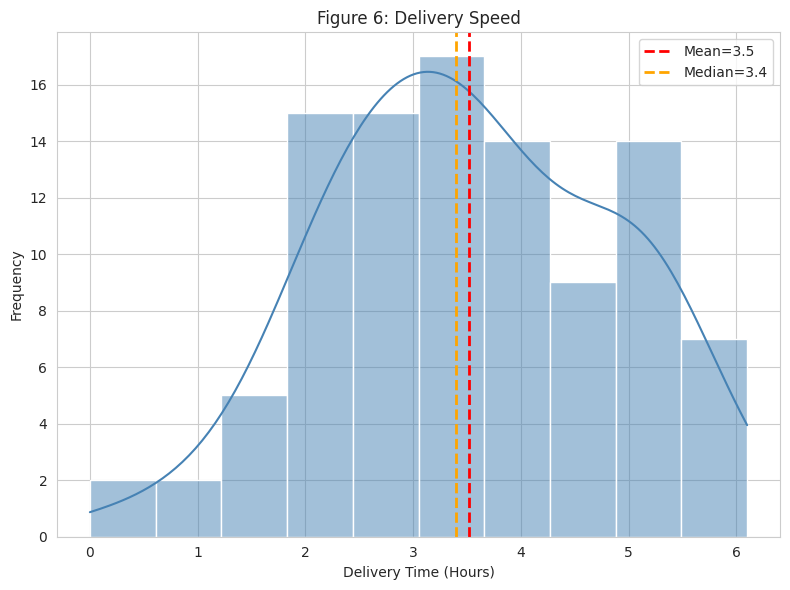

Saved: plots/Figure_06_delivery_speed.png


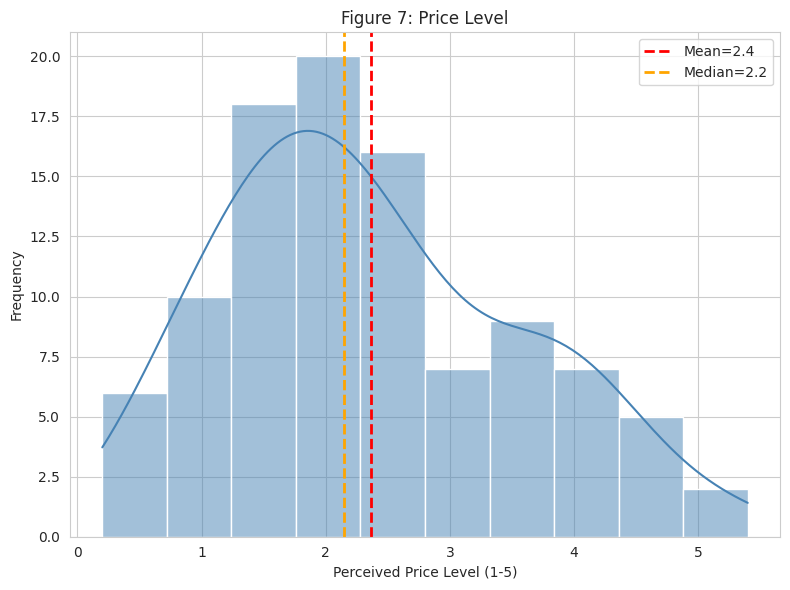

Saved: plots/Figure_07_price_level.png


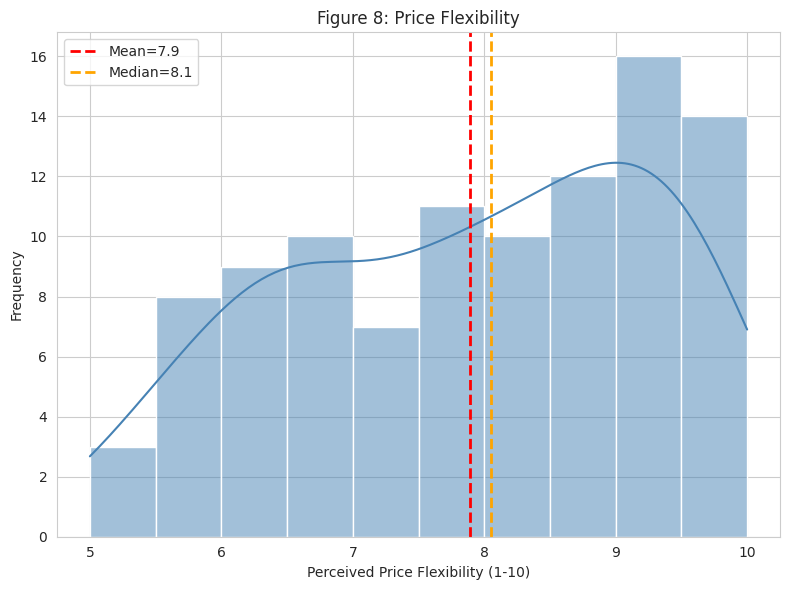

Saved: plots/Figure_08_price_flexibility.png


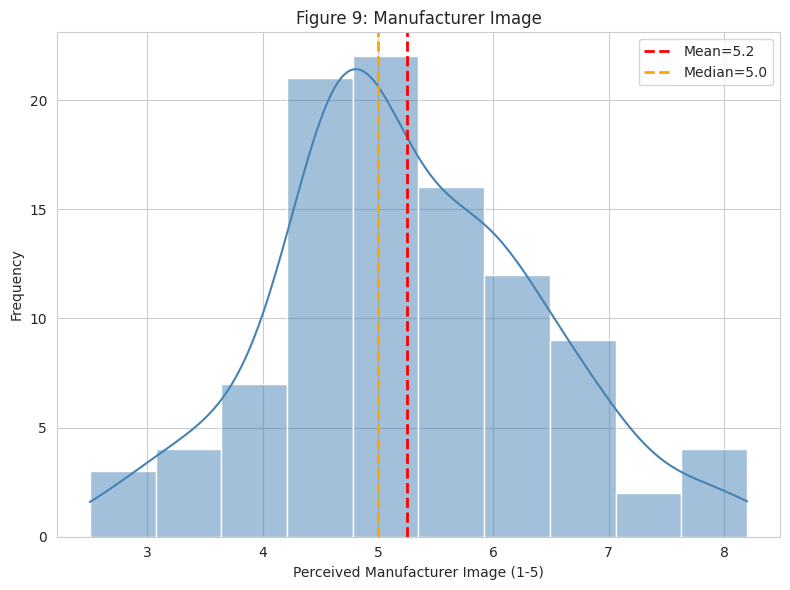

Saved: plots/Figure_09_manufacturer_image.png


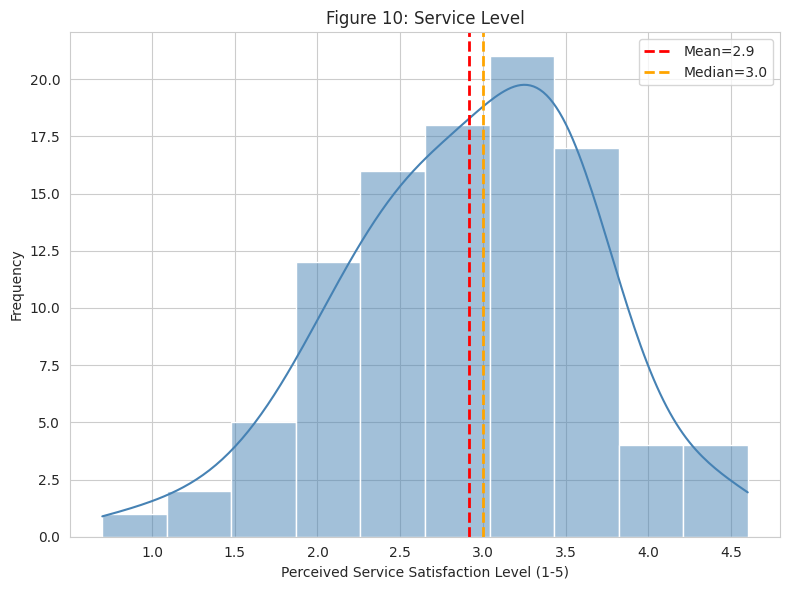

Saved: plots/Figure_10_service_level.png


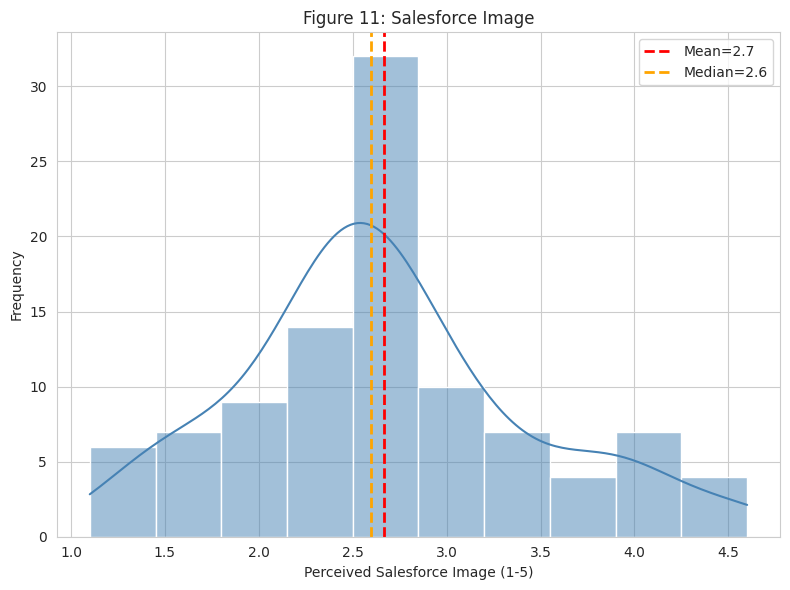

Saved: plots/Figure_11_salesforce_image.png


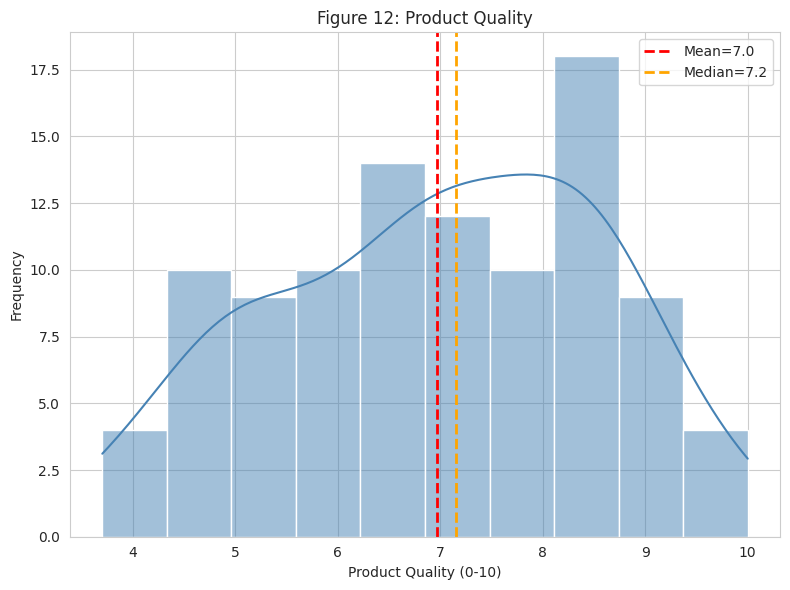

Saved: plots/Figure_12_product_quality.png


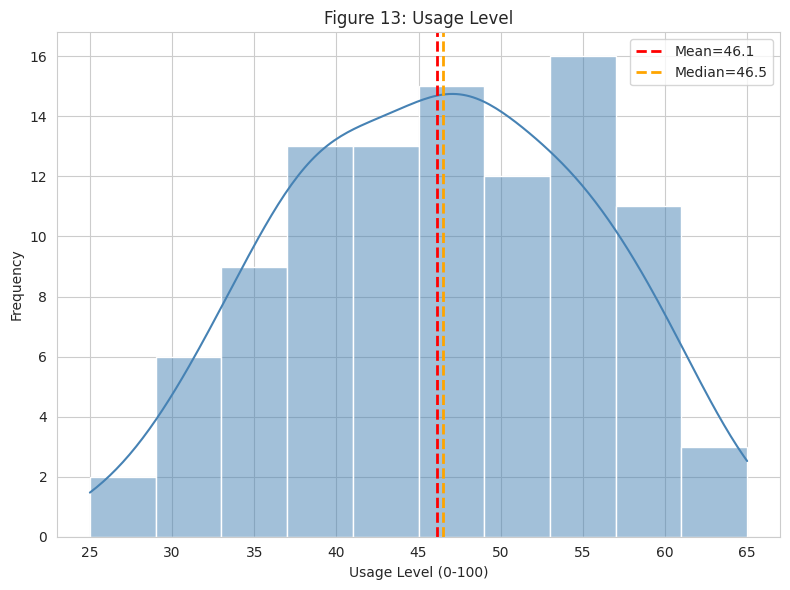

Saved: plots/Figure_13_usage_level.png


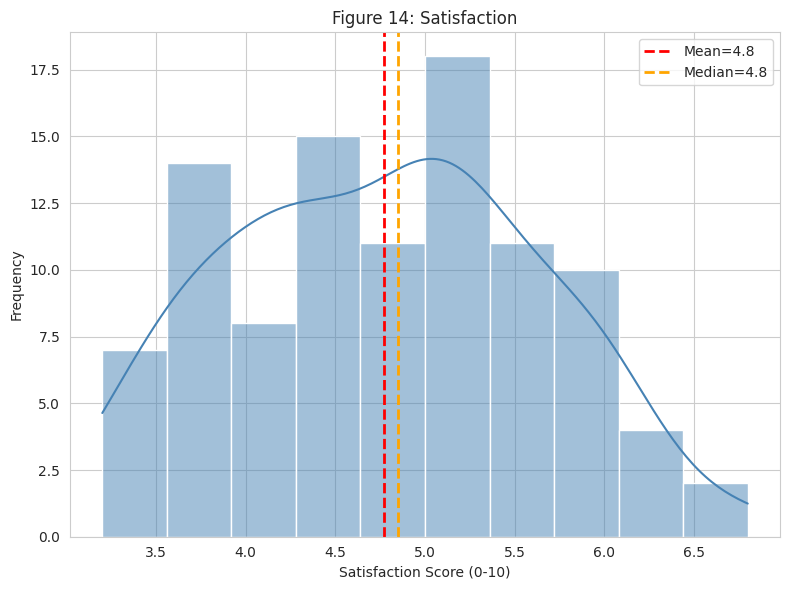

Saved: plots/Figure_14_satisfaction.png
All histograms saved separately.


In [21]:
# ─────────────────────────────────────────────
#  SECTION 2D — HISTOGRAMS (Metric)
# ─────────────────────────────────────────────

x_labels_dict = {
    0: 'Delivery Time (Hours)',
    1: 'Perceived Price Level (1-5)',
    2: 'Perceived Price Flexibility (1-10)',
    3: 'Perceived Manufacturer Image (1-5)',
    4: 'Perceived Service Satisfaction Level (1-5)',
    5: 'Perceived Salesforce Image (1-5)',
    6: 'Product Quality (0-10)',
    7: 'Usage Level (0-100)',
    8: 'Satisfaction Score (0-10)',
}

os.makedirs('plots', exist_ok=True)

for i, col in enumerate(metric_cols):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.histplot(df[col], bins=10, ax=ax, color='steelblue', kde=True)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=2, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=2, label=f'Median={df[col].median():.1f}')
    ax.set_title(f'Figure {i+6}: {col.replace("_"," ").title()}')
    ax.set_xlabel(x_labels_dict.get(i, 'Value'))
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=10)
    plt.tight_layout()
    filename = f'plots/Figure_{i+6:02d}_{col}.png'
    plt.savefig(filename)
    plt.show()
    plt.close()
    print(f"Saved: {filename}")

print("All histograms saved separately.")



========== ONE-WAY ANOVA ==========
Q: Does Price Level differ among Small, Medium, Large firms?
H0: mean_small = mean_medium = mean_large
H1: At least one mean differs

Small firms (n=30): mean=2.01, std=1.03

Medium firms (n=38): mean=2.83, std=1.29

Large firms (n=32): mean=2.15, std=1.08

--- Normality Test ---


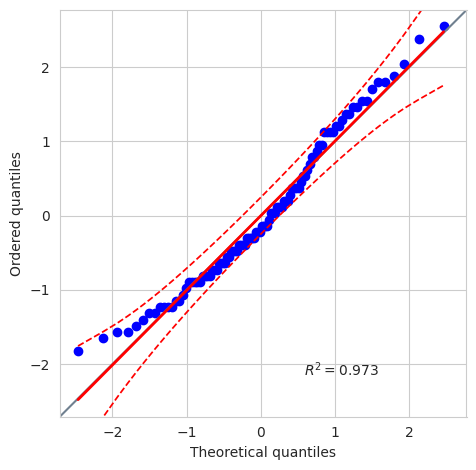

Saved: plots/Figure_17_price_level_normality_qqplot.png
                   W      pval  normal
price_level  0.96851  0.017019   False
                                     OK

--- Homogeneity of Variance ---
               W      pval  equal_var
levene  1.597625  0.207655       True
                                  OK

--- One-Way ANOVA ---
      Source  ddof1  ddof2         F     p_unc       np2
0  firm_size      2     97  5.136595  0.007579  0.095767

Means by group:
firm_size
0    2.006667
1    2.828947
2    2.146875
Name: price_level, dtype: float64


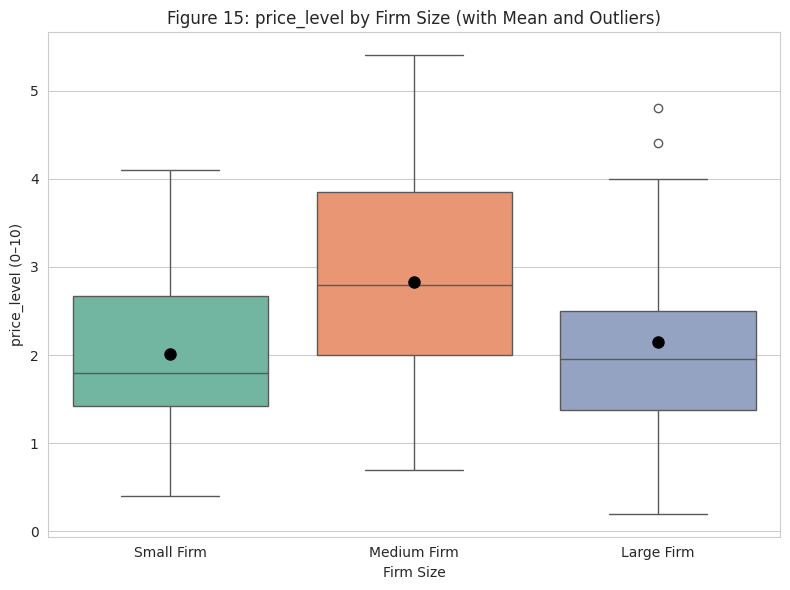

Saved: plots/Figure_15_anova_boxplot_with_mean_outliers.png


In [22]:
# ─────────────────────────────────────────────
#  SECTION 3A — ONE-WAY ANOVA
#  Q: Does Price Level differ by firm size?
#  IV:   (0=Small, 1=Medium, 2=Large)
#  DV: Price Level
# ─────────────────────────────────────────────

print("\n========== ONE-WAY ANOVA ==========")
unique_sizes = sorted(df['firm_size'].unique())
group_names = [labels['firm_size'][s] for s in unique_sizes]
print(f"Q: Does Price Level differ among {', '.join(group_names)} firms?")
h0_parts = ' = '.join([f'mean_{name.lower()}' for name in group_names])
print(f"H0: {h0_parts}")
print("H1: At least one mean differs")

# Split groups
groups = [df[df['firm_size'] == s]['price_level'] for s in unique_sizes]
for name, group in zip(group_names, groups):
    print(f"\n{name} firms (n={len(group)}): mean={group.mean():.2f}, std={group.std():.2f}")

# --- Step 1: Normality test ---
print("\n--- Normality Test ---")
ax = pg.qqplot(df["price_level"], dist='norm')
plt.tight_layout()
plt.savefig('plots/Figure_17_price_level_normality_qqplot.png')
plt.show()
plt.close()
print("Saved: plots/Figure_17_price_level_normality_qqplot.png")
print(pg.normality(df["price_level"]))
print("                                     OK")   #H0: DV is in N.Dist

# --- Step 2: Homogeneity of Variance ---
print("\n--- Homogeneity of Variance ---")
print(pg.homoscedasticity(data=df, dv='price_level', group='firm_size'))
print("                                  OK")   #H0: DV is homogenies

# --- Step 3: One-Way ANOVA ---
print("\n--- One-Way ANOVA ---")
anova_result = pg.anova(data=df, dv="price_level", between='firm_size', detailed=False)
print(anova_result)

print("\nMeans by group:")
print(df.groupby('firm_size')['price_level'].mean())

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='firm_size', y='price_level', ax=ax, palette='Set2', showfliers=True, showmeans=True,
            meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"black", "markersize":"8"})
ax.set_title('Figure 15: price_level by Firm Size (with Mean and Outliers)')
ax.set_xlabel('Firm Size')
ax.set_ylabel('price_level (0–10)')
box_labels = [labels['firm_size'][s] + ' Firm' for s in unique_sizes]
ax.set_xticklabels(box_labels)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/Figure_15_anova_boxplot_with_mean_outliers.png')
plt.show()
plt.close()
print("Saved: plots/Figure_15_anova_boxplot_with_mean_outliers.png")

### Post-hoc Analysis: Tukey HSD

In [23]:
# Perform Tukey HSD post-hoc test
tukey_result = pg.pairwise_tukey(data=df, dv='price_level', between='firm_size')
print(tukey_result)

# Interpretation
print("\n--- Tukey HSD Post-hoc Test Interpretation ---")
alpha = 0.05
for index, row in tukey_result.iterrows():
    pair = f"{labels['firm_size'][row['A']]} vs {labels['firm_size'][row['B']]}"
    if row['p_tukey'] < alpha:
        print(f"*   {pair}: Significant difference (p={row['p_tukey']:.4f}) - Reject H0 that means are equal")
    else:
        print(f"*   {pair}: No significant difference (p={row['p_tukey']:.4f}) - Fail to reject H0 that means are equal")

   A  B    mean_A    mean_B      diff        se         T   p_tukey    hedges
0  0  1  2.006667  2.828947 -0.822281  0.280531 -2.931155  0.011630 -0.688980
1  0  2  2.006667  2.146875 -0.140208  0.291904 -0.480324  0.880761 -0.131352
2  1  2  2.828947  2.146875  0.682072  0.275589  2.474964  0.039610  0.563548

--- Tukey HSD Post-hoc Test Interpretation ---
*   Small vs Medium: Significant difference (p=0.0116) - Reject H0 that means are equal
*   Small vs Large: No significant difference (p=0.8808) - Fail to reject H0 that means are equal
*   Medium vs Large: Significant difference (p=0.0396) - Reject H0 that means are equal


### Tukey HSD Post-Hoc Test Results Summary

This table shows the pairwise comparisons between firm sizes. A p-value less than 0.05 indicates a statistically significant difference between the means of the two groups.

In [24]:
display(tukey_result[['A', 'B', 'diff', 'p_tukey', 'hedges']])

,A,B,diff,p_tukey,hedges
0,0,1,-0.822281,0.011630,-0.688980
1,0,2,-0.140208,0.880761,-0.131352
2,1,2,0.682072,0.039610,0.563548



========== MANOVA ==========
Q: Does the combination of (manufacturer image, salesforce image) differ by firm size?
H0: No difference in centroid among Small, Medium, Large firms
H1: Centroid differs among groups


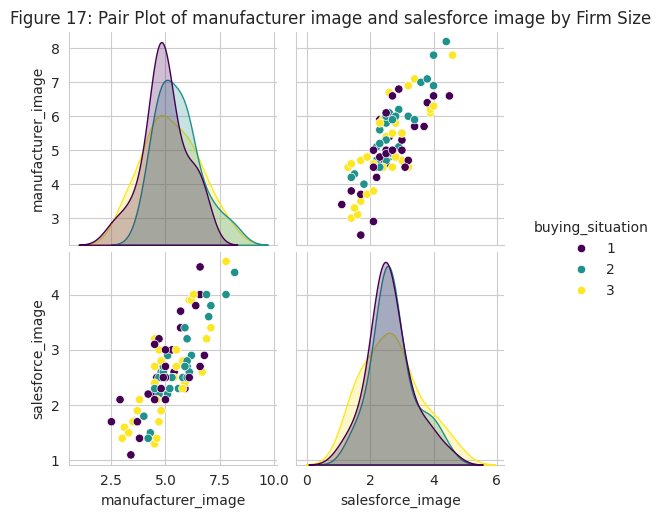

Saved: plots/Figure_17_manova_pairplot.png


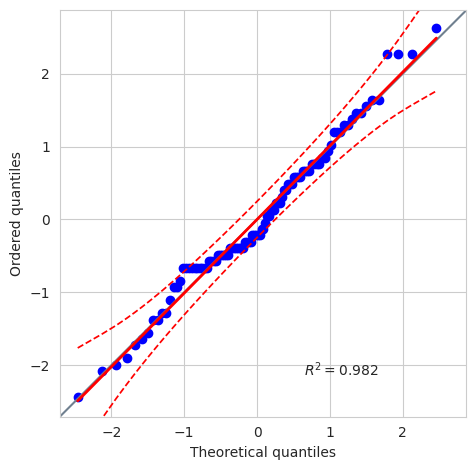

Saved: plots/Figure_18_manufacturer_image_normality_qqplot.png
Normality test for manufacturer_image:
                         W      pval  normal
manufacturer_image  0.9818  0.183162    True


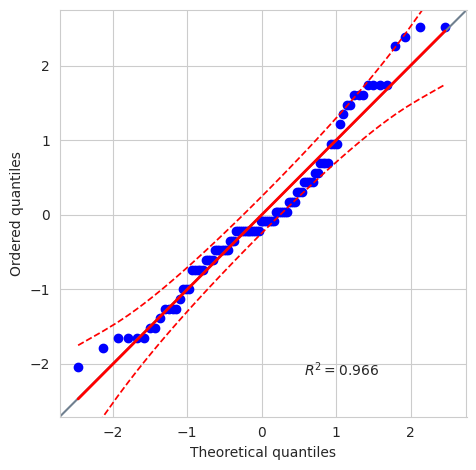

Saved: plots/Figure_19_salesforce_image_normality_qqplot.png
Normality test for salesforce_image:
                         W      pval  normal
salesforce_image  0.963413  0.007094   False

Optimal Box-Cox Lambda for salesforce_image: 0.3979


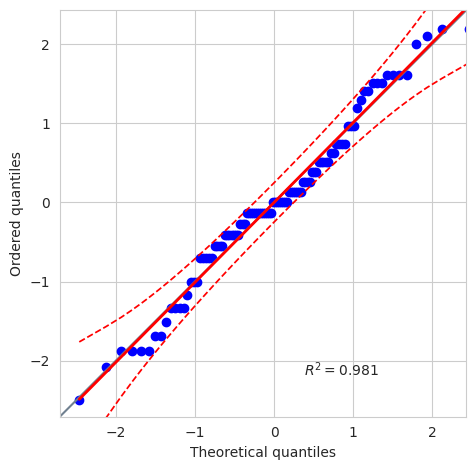

Saved: plots/Figure_20_salesforce_image_bc_normality_qqplot.png
Normality test for salesforce_image_bc:
                            W      pval  normal
salesforce_image_bc  0.978127  0.094898    True

Normality by buying_situation for salesforce_image_bc:
                         W      pval  normal
buying_situation                            
1                 0.971019  0.490124    True
2                 0.960552  0.284371    True
3                 0.970300  0.469802    True

Box's M test:
          Chi2   df      pval  equal_cov
box  12.506458  6.0  0.051578       True

Homoscedasticity tests:
manufacturer_image homoscedasticity result:
               W      pval  equal_var
levene  1.999337  0.140968       True
salesforce_image homoscedasticity result:
               W      pval  equal_var
levene  1.779353  0.174211       True
salesforce_image_bc homoscedasticity result:
               W     pval  equal_var
levene  1.996959  0.14129       True

Firm size value counts:
buying_situatio

In [25]:
# ─────────────────────────────────────────────
#  SECTION 3B — MANOVA
#  Q: Does the OVERALL perception pattern
#     (manufacturer image + salesforce image) differ by firm size?
#  IV:  buying_situation (0=New task, 1=Modified re-buy, 2=Straight re-buy)
#  DVs: manufacturer_image, salesforce_image
# ─────────────────────────────────────────────

print("\n========== MANOVA ==========")
print("Q: Does the combination of (manufacturer image, salesforce image) differ by firm size?")
h0_manova = "No difference in centroid among " + ', '.join(group_names) + " firms"
print(f"H0: {h0_manova}")
print("H1: Centroid differs among groups")

dv_cols = ['manufacturer_image', 'salesforce_image']

# test multi normality
Iv = df["buying_situation"]
Dvs = ["manufacturer_image","salesforce_image"]

# Visualization
fig = sns.pairplot(df, vars=['manufacturer_image', 'salesforce_image'], hue='buying_situation', palette='viridis', diag_kind='kde')
fig.fig.suptitle('Figure 17: Pair Plot of manufacturer image and salesforce image by Firm Size', y=1.02) # Adjust title position

os.makedirs('plots', exist_ok=True)
plt.savefig('plots/Figure_17_manova_pairplot.png')
plt.show()
plt.close()
print("Saved: plots/Figure_17_manova_pairplot.png")

fig_num = 18
for i in Dvs:
    ax = pg.qqplot(df[i], dist='norm')
    plt.tight_layout()
    plt.savefig(f'plots/Figure_{fig_num:02d}_{i}_normality_qqplot.png')
    plt.show()
    plt.close()
    print(f"Saved: plots/Figure_{fig_num:02d}_{i}_normality_qqplot.png")
    print(f"Normality test for {i}:")
    print(pg.normality(df[i]))
    fig_num += 1

# Box-Cox for salesforce_image
df['salesforce_image_bc'], best_lambda = boxcox(df['salesforce_image'])
print(f"\nOptimal Box-Cox Lambda for salesforce_image: {best_lambda:.4f}")

ax = pg.qqplot(df["salesforce_image_bc"], dist='norm')
plt.tight_layout()
plt.savefig(f'plots/Figure_{fig_num:02d}_salesforce_image_bc_normality_qqplot.png')
plt.show()
plt.close()
print(f"Saved: plots/Figure_{fig_num:02d}_salesforce_image_bc_normality_qqplot.png")
print("Normality test for salesforce_image_bc:")
print(pg.normality(df["salesforce_image_bc"]))

# Normality by group
print("\nNormality by buying_situation for salesforce_image_bc:")
print(pg.normality(data=df, dv='salesforce_image_bc', group='buying_situation'))

# Box's M test
print("\nBox's M test:")
box_m_result = pg.box_m(data=df, dvs=dv_cols, group='buying_situation') # Corrected dvs to dv_cols
print(box_m_result)

# Homoscedasticity
print("\nHomoscedasticity tests:")
Dvs_with_bc = ["manufacturer_image", "salesforce_image","salesforce_image_bc"] # Added manufacturer_image for homoscedasticity
for i in Dvs_with_bc:
    print(f"{i} homoscedasticity result:")
    print(pg.homoscedasticity(data=df, dv=i, group='buying_situation'))

print("\nFirm size value counts:")
print(df['buying_situation'].value_counts())

# Wilks' Lambda (manual calculation for g groups)
groups_data = [df[df['buying_situation'] == s][dv_cols].values for s in unique_sizes]
g = len(unique_sizes)
n_list = [group.shape[0] for group in groups_data]
n = sum(n_list)
p = len(dv_cols)

# Grand mean
grand_mean = df[dv_cols].values.mean(axis=0)

# Group means
group_means = [group.mean(axis=0) for group in groups_data]

# Within-group scatter matrix W
W = np.zeros((p, p))
for group, mean_vec in zip(groups_data, group_means):
    for x in group:
        d = (x - mean_vec).reshape(-1, 1)
        W += d @ d.T

# Total scatter matrix T
all_data = df[dv_cols].values
T = np.zeros((p, p))
for x in all_data:
    d = (x - grand_mean).reshape(-1, 1)
    T += d @ d.T

# Between-group scatter matrix B = T - W
B = T - W

# Wilks' Lambda = det(W) / det(T)
wilks_lambda = np.linalg.det(W) / np.linalg.det(T)

# Approx F-test for Wilks' Lambda (g groups)
df_h = p * (g - 1)          # hypothesis df
df_e = p * (n - g)          # error df
F_approx = ((1 - wilks_lambda) / wilks_lambda) * (df_e / df_h)
p_manova  = 1 - stats.f.cdf(F_approx, df_h, df_e)

print(f"\nWilks' Lambda = {wilks_lambda:.4f}")
print(f"Approx F({df_h}, {df_e}) = {F_approx:.4f},  p = {p_manova:.4f}")
if p_manova < 0.05:
    print("Decision: REJECT H0 - Significant multivariate difference in perception pattern")
else:
    print("Decision: FAIL TO REJECT H0 - No significant multivariate difference")

# Univariate follow-up ANOVAs
print("\n--- Univariate Follow-up ANOVAs (for each DV) ---")
for col in dv_cols:
    group_cols = [df[df['buying_situation'] == s][col] for s in unique_sizes]
    f, p = stats.f_oneway(*group_cols)
    sig = '* significant' if p < 0.05 else '  not significant'
    print(f"  {col:<22}: F={f:.3f}, p={p:.4f}  {sig}")

# MANOVA with statsmodels
print("\n--- MANOVA (statsmodels) ---")
manova = MANOVA.from_formula('manufacturer_image + salesforce_image ~ C(buying_situation)', data=df) # Corrected formula
results = manova.mv_test()
print(results)

### Post-hoc Analysis for MANOVA Follow-up: Tukey HSD for `manufacturer_image`

In [26]:
# Perform Tukey HSD post-hoc test for manufacturer_image
tukey_manufacturer_image = pg.pairwise_tukey(data=df, dv='manufacturer_image', between='firm_size')
print(tukey_manufacturer_image)

# Interpretation
print("\n--- Tukey HSD Post-hoc Test Interpretation for manufacturer_image ---")
alpha = 0.05
for index, row in tukey_manufacturer_image.iterrows():
    pair = f"{labels['firm_size'][row['A']]} vs {labels['buying_situation'][row['B']]}"
    if row['p_tukey'] < alpha:
        print(f"*   {pair}: Significant difference (p={row['p_tukey']:.4f}) - Reject H0 that means are equal")
    else:
        print(f"*   {pair}: No significant difference (p={row['p_tukey']:.4f}) - Fail to reject H0 that means are equal")

   A  B    mean_A    mean_B      diff        se         T   p_tukey    hedges
0  0  1  4.630000  5.568421 -0.938421  0.260207 -3.606438  0.001419 -0.966058
1  0  2  4.630000  5.446875 -0.816875  0.270756 -3.017020  0.009066 -0.764334
2  1  2  5.568421  5.446875  0.121546  0.255623  0.475490  0.883000  0.103048

--- Tukey HSD Post-hoc Test Interpretation for manufacturer_image ---
*   Small vs New Task: Significant difference (p=0.0014) - Reject H0 that means are equal
*   Small vs Modified Rebuy: Significant difference (p=0.0091) - Reject H0 that means are equal
*   Medium vs Modified Rebuy: No significant difference (p=0.8830) - Fail to reject H0 that means are equal


### Tukey HSD Post-Hoc Test Results Summary for `manufacturer_image`

In [27]:
display(tukey_manufacturer_image[['A', 'B', 'diff', 'p_tukey', 'hedges']])

,A,B,diff,p_tukey,hedges
0,0,1,-0.938421,0.001419,-0.966058
1,0,2,-0.816875,0.009066,-0.764334
2,1,2,0.121546,0.883000,0.103048


### Post-hoc Analysis for MANOVA Follow-up: Tukey HSD for `salesforce_image`

In [28]:
# Perform Tukey HSD post-hoc test for salesforce_image
tukey_salesforce_image = pg.pairwise_tukey(data=df, dv='salesforce_image', between='firm_size')
print(tukey_salesforce_image)

# Interpretation
print("\n--- Tukey HSD Post-hoc Test Interpretation for salesforce_image ---")
alpha = 0.05
for index, row in tukey_salesforce_image.iterrows():
    pair = f"{labels['firm_size'][row['A']]} vs {labels['buying_situation'][row['B']]}"
    if row['p_tukey'] < alpha:
        print(f"*   {pair}: Significant difference (p={row['p_tukey']:.4f}) - Reject H0 that means are equal")
    else:
        print(f"*   {pair}: No significant difference (p={row['p_tukey']:.4f}) - Fail to reject H0 that means are equal")

   A  B    mean_A    mean_B      diff        se         T   p_tukey    hedges
0  0  1  2.360000  2.768421 -0.408421  0.183536 -2.225285  0.071969 -0.600539
1  0  2  2.360000  2.828125 -0.468125  0.190977 -2.451214  0.042022 -0.608919
2  1  2  2.768421  2.828125 -0.059704  0.180303 -0.331131  0.941388 -0.072462

--- Tukey HSD Post-hoc Test Interpretation for salesforce_image ---
*   Small vs New Task: No significant difference (p=0.0720) - Fail to reject H0 that means are equal
*   Small vs Modified Rebuy: Significant difference (p=0.0420) - Reject H0 that means are equal
*   Medium vs Modified Rebuy: No significant difference (p=0.9414) - Fail to reject H0 that means are equal


### Tukey HSD Post-Hoc Test Results Summary for `salesforce_image`

In [29]:
display(tukey_salesforce_image[['A', 'B', 'diff', 'p_tukey', 'hedges']])

,A,B,diff,p_tukey,hedges
0,0,1,-0.408421,0.071969,-0.600539
1,0,2,-0.468125,0.042022,-0.608919
2,1,2,-0.059704,0.941388,-0.072462
